# Dual Optimal Halpern Method (Dual-OHM)

This code outlines the procedure for Lyapunov function discovery for the
Dual Optimal Halpern Method, proposed in "Optimal Acceleration for Minimax
and Fixed-Point Problems is Not Unique" by Yoon, Kim, Suh and Ryu (2024)
as another exact optimal method for reducing the residual norm $\|y - Ty\|$
for nonexpansive fixed-point operator $T$, or equivalently $\|\tilde{A}x\|$
for $x = J_A(y)$ where A is the maximally monotone operator satisfying
$T = 2J_A - I$.

## Import the required libraries

In [1]:
import pepflow as pf
import pepflow.lyapunov_utils as lu
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from itertools import combinations
from IPython.display import display, Math

## Define the operators

In [2]:
A = pf.MonotoneOperator(is_basis=True, tags=["A"])

## Write a function that generates a PEPContext object associated with Dual-OHM

In [3]:
def make_ctx_dual_ohm(ctx_name: str, N: int | sp.Integer) -> pf.PEPContext:
    ctx_dual_ohm = pf.PEPContext(ctx_name).set_as_current()
    y = pf.Vector(is_basis=True, tags=["y_0"])
    A.set_zero_point("y_star")

    Ty_prev = y
    for i in range(N):
        x = A.resolvent(y, sp.S(1), tag=f"x_{i + 1}")
        Ty = sp.S(2) * x - y
        factor = (sp.S(N) - sp.S(i) - sp.S(1)) / (sp.S(N) - sp.S(i))
        y = (y + factor * (Ty - Ty_prev)).add_tag(f"y_{i + 1}")
        Ty_prev = Ty

    return ctx_dual_ohm

## Numerical evidence showing that Dual-OHM converges at the rate $\|A x_N\|^2 \le \frac{\|y_0-y_\star\|^2}{N^2}$

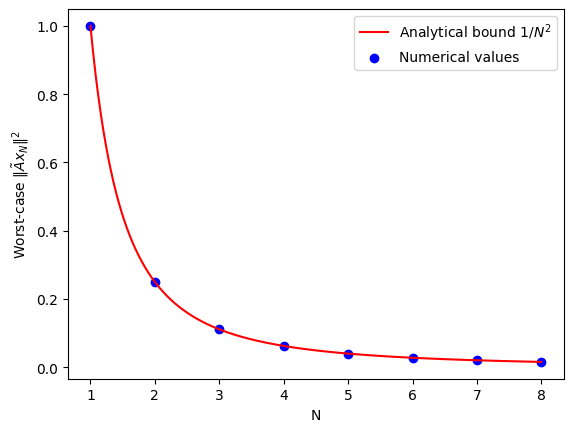

In [4]:
N_max = 8
R = pf.Parameter("R")
R_value = 1

opt_values = []
for N in range(1, N_max + 1):
    ctx_N = make_ctx_dual_ohm(ctx_name=f"ctx_{N}", N=N)
    pb_plt = pf.PEPBuilder(ctx_N)
    pb_plt.add_initial_constraint(
        ((ctx_N["y_0"] - ctx_N["y_star"]) ** 2).le(R, name="initial_condition")
    )
    pb_plt.set_performance_metric(A(ctx_N[f"x_{N}"]) ** 2)
    result = pb_plt.solve(resolve_parameters={"R": R_value})
    opt_values.append(result.opt_value)

iters = np.arange(1, N_max + 1)
cont_iters = np.arange(1, N_max + 0.01, 0.01)
plt.plot(cont_iters, 1 / cont_iters**2, "r-", label="Analytical bound $1/N^2$")
plt.scatter(iters, opt_values, color="blue", marker="o", label="Numerical values")
plt.xlabel("N")
plt.ylabel(r"Worst-case $\|\tilde{A} x_N\|^2$")
plt.legend()

## Verification of convergence of Dual-OHM

In [5]:
N = sp.S(6)
R_value = sp.S(1)

ctx_prf = make_ctx_dual_ohm(ctx_name="ctx_prf", N=N)
pb_prf = pf.PEPBuilder(ctx_prf)
pb_prf.add_initial_constraint(
    ((ctx_prf["y_0"] - ctx_prf["y_star"]) ** 2).le(R, name="initial_condition")
)
pb_prf.set_performance_metric(A(ctx_prf[f"x_{N}"]) ** 2)

result = pb_prf.solve(resolve_parameters={"R": R_value})
print(result.opt_value)

# Dense dual variables associated with the interpolation conditions of A.
lamb_dense = result.get_scalar_constraint_dual_value_in_numpy(A)

0.02777151522779022


### No relaxation of the dual variables is needed, so we store the solver output

In [6]:
# Dual variable associated with the initial condition.
tau_sol = result.dual_var_manager.dual_value("initial_condition")

# Dual variables associated with the interpolation conditions of A.
lamb_sol = result.get_scalar_constraint_dual_value_in_numpy(A)

# Dual variable associated with the Gram matrix.
S_sol = result.get_gram_dual_matrix()

In [7]:
lamb_sol.pprint()

<IPython.core.display.Math object>

In [8]:
S_sol.pprint()

<IPython.core.display.Math object>

### The Gram dual matrix $S$ has rank 1

In [9]:
np.linalg.matrix_rank(S_sol.matrix)

np.int64(1)

---

## Step 1. Propose a candidate Lyapunov function

### Choose $\mathcal{I}_k = \{(N,j): j=1,\dots,k\}, \mathcal{I}_0 = \emptyset, \mathcal{J}_k = \emptyset$.

In [10]:
lyap = [pf.Scalar.zero()]
partial_sum = pf.Scalar.zero()
for j in np.arange(1, N):
    partial_sum += lamb_sol(f"x_{j}", f"x_{N}") * A.interp_ineq(f"x_{j}", f"x_{N}")
    lyap.append(partial_sum)

## Step 2. Check for admissibility

### Sufficiency is immediate.
### The rank pattern for $\mathbf{V}_k$ is $2,4,\dots,4,2$ excluding $k=0$: the interior rank is consistently $4$.

In [11]:
pm = pf.ExpressionManager(ctx_prf, resolve_parameters={})

for k in range(len(lyap)):
    lyap_numeric_k = pm.eval_scalar(lyap[k]).inner_prod_coords.astype(float)
    print(f"Rank of lyap[{k}]: {np.linalg.matrix_rank(lyap_numeric_k, tol=1e-5)}")

Rank of lyap[0]: 0
Rank of lyap[1]: 2
Rank of lyap[2]: 4
Rank of lyap[3]: 4
Rank of lyap[4]: 4
Rank of lyap[5]: 2


## Step 3. Build a set of special candidate vectors

In [12]:
lyap_basis_candidate = ctx_prf.basis_vectors()

x = [ctx_prf[f"x_{i}"] for i in range(1, N + 1)]
y = [ctx_prf[f"y_{i}"] for i in range(1, N)]
lyap_basis_candidate += x + y

for i in range(1, N + 1):
    Ty = sp.S(2) * ctx_prf[f"x_{i}"] - ctx_prf[f"y_{i - 1}"]
    Ty.add_tag(f"Ty_{i - 1}")
    lyap_basis_candidate.append(Ty)

base_count = len(lyap_basis_candidate)
for i, j in combinations(range(base_count), 2):
    diff = lyap_basis_candidate[i] - lyap_basis_candidate[j]
    diff.add_tag(f"{lyap_basis_candidate[i].tag}-{lyap_basis_candidate[j].tag}")
    lyap_basis_candidate.append(diff)

In [13]:
print(lyap_basis_candidate)

[y_0, y_star, A(x_1), A(x_2), A(x_3), A(x_4), A(x_5), A(x_6), x_1, x_2, x_3, x_4, x_5, x_6, y_1, y_2, y_3, y_4, y_5, Ty_0, Ty_1, Ty_2, Ty_3, Ty_4, Ty_5, y_0-y_star, y_0-A(x_1), y_0-A(x_2), y_0-A(x_3), y_0-A(x_4), y_0-A(x_5), y_0-A(x_6), y_0-x_1, y_0-x_2, y_0-x_3, y_0-x_4, y_0-x_5, y_0-x_6, y_0-y_1, y_0-y_2, y_0-y_3, y_0-y_4, y_0-y_5, y_0-Ty_0, y_0-Ty_1, y_0-Ty_2, y_0-Ty_3, y_0-Ty_4, y_0-Ty_5, y_star-A(x_1), y_star-A(x_2), y_star-A(x_3), y_star-A(x_4), y_star-A(x_5), y_star-A(x_6), y_star-x_1, y_star-x_2, y_star-x_3, y_star-x_4, y_star-x_5, y_star-x_6, y_star-y_1, y_star-y_2, y_star-y_3, y_star-y_4, y_star-y_5, y_star-Ty_0, y_star-Ty_1, y_star-Ty_2, y_star-Ty_3, y_star-Ty_4, y_star-Ty_5, A(x_1)-A(x_2), A(x_1)-A(x_3), A(x_1)-A(x_4), A(x_1)-A(x_5), A(x_1)-A(x_6), A(x_1)-x_1, A(x_1)-x_2, A(x_1)-x_3, A(x_1)-x_4, A(x_1)-x_5, A(x_1)-x_6, A(x_1)-y_1, A(x_1)-y_2, A(x_1)-y_3, A(x_1)-y_4, A(x_1)-y_5, A(x_1)-Ty_0, A(x_1)-Ty_1, A(x_1)-Ty_2, A(x_1)-Ty_3, A(x_1)-Ty_4, A(x_1)-Ty_5, A(x_2)-A(x_3), A(x_

## Step 4. Find a basis of $\mathbf{V}_k$ within the candidate vectors

### Inspect the aligned vectors and then fix the persistent vectors $\tilde{A} x_N$ and $y_0-x_N$

In [14]:
aligned_vectors_by_k = {}
for k in range(len(lyap)):
    aligned_vectors_k = lu.vectors_in_column_space(
        lyap[k],
        lyap_basis_candidate,
        pep_context=ctx_prf,
        resolve_parameters={},
        rtol=1e-5,
        atol=1e-5,
    )
    aligned_vectors_by_k[k] = aligned_vectors_k
    print(f"V_{k}:")
    print(aligned_vectors_k)

V_0:
[]
V_1:
[y_0-y_5, A(x_1)-A(x_6), x_1-x_6, Ty_0-Ty_5]
V_2:
[A(x_1), A(x_2), A(x_6), y_0-x_1, y_0-x_2, y_0-x_6, y_0-y_1, y_0-y_2, y_0-y_5, y_0-Ty_0, y_0-Ty_1, y_0-Ty_5, A(x_1)-A(x_2), A(x_1)-A(x_6), A(x_2)-A(x_6), x_1-x_2, x_1-x_6, x_1-y_1, x_1-y_2, x_1-y_5, x_1-Ty_0, x_1-Ty_1, x_1-Ty_5, x_2-x_6, x_2-y_1, x_2-y_2, x_2-y_5, x_2-Ty_0, x_2-Ty_1, x_2-Ty_5, x_6-y_1, x_6-y_2, x_6-y_5, x_6-Ty_0, x_6-Ty_1, x_6-Ty_5, y_1-y_2, y_1-y_5, y_1-Ty_0, y_1-Ty_1, y_1-Ty_5, y_2-y_5, y_2-Ty_0, y_2-Ty_1, y_2-Ty_5, y_5-Ty_0, y_5-Ty_1, y_5-Ty_5, Ty_0-Ty_1, Ty_0-Ty_5, Ty_1-Ty_5]
V_3:
[A(x_6), y_0-x_6, y_0-y_3, y_0-y_5, y_0-Ty_2, y_0-Ty_5, x_6-y_3, x_6-y_5, x_6-Ty_2, x_6-Ty_5, y_3-y_5, y_3-Ty_2, y_3-Ty_5, y_5-Ty_2, y_5-Ty_5, Ty_2-Ty_5]
V_4:
[A(x_5), A(x_6), y_0-x_5, y_0-x_6, y_0-y_4, y_0-y_5, y_0-Ty_3, y_0-Ty_4, y_0-Ty_5, A(x_5)-A(x_6), x_5-x_6, x_5-y_4, x_5-y_5, x_5-Ty_3, x_5-Ty_4, x_5-Ty_5, x_6-y_4, x_6-y_5, x_6-Ty_3, x_6-Ty_4, x_6-Ty_5, y_4-y_5, y_4-Ty_3, y_4-Ty_4, y_4-Ty_5, y_5-Ty_3, y_5-Ty_4, y_5-Ty_5,

### Fix those two vectors and search for a completed basis with the sparsest decomposition 

In [15]:
fixed_vectors = [ctx_prf[f"A(x_{N})"], ctx_prf[f"y_0-x_{N}"]]

for k in range(2, len(lyap)):
    print(f"V_{k}:")
    print("Fixing:", fixed_vectors)
    best_vectors, best_coefficients = lu.find_basis_with_sparsest_coefficients(
        lyap[k],
        aligned_vectors_by_k[k],
        pep_context=ctx_prf,
        resolve_parameters={},
        fixed_vectors=fixed_vectors,
        zero_tol=1e-3,
        indep_tol=1e-5,
    )
    labels_k = [str(v) for v in best_vectors]
    print("Sparsest basis:", best_vectors)
    pf.pprint_labeled_matrix(best_coefficients, labels_k, labels_k)
    print()

V_2:
Fixing: [A(x_6), y_0-x_6]


C:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\lyapunov_utils.py:387: UserWarning:

Exhaustive subset search may be slow: checking 1176 subsets.



Sparsest basis: [A(x_6), y_0-x_6, y_2-y_5, Ty_1-Ty_5]


<IPython.core.display.Math object>


V_3:
Fixing: [A(x_6), y_0-x_6]
Sparsest basis: [A(x_6), y_0-x_6, y_3-y_5, Ty_2-Ty_5]


<IPython.core.display.Math object>


V_4:
Fixing: [A(x_6), y_0-x_6]
Sparsest basis: [A(x_6), y_0-x_6, A(x_5)-A(x_6), x_5-x_6]


<IPython.core.display.Math object>


V_5:
Fixing: [A(x_6), y_0-x_6]
Sparsest basis: [A(x_6), y_0-x_6]


<IPython.core.display.Math object>

### The above suggests that $\{\tilde{A}x_N, y_0 - x_N, y_k - y_{N-1}, Ty_{k-1} - Ty_{N-1}\}$ is a basis.
### Numerically inspecting the coefficient matrices show that coefficients for $\tilde{A}x_N, y_0 - x_N$ terms are constants: subtract these terms and let
$$
    \widetilde V_k
    = a_k\|y_k-y_{N-1}\|^2
      + \langle y_k-y_{N-1}, T y_{k-1}-T y_{N-1}\rangle
      + b_k\|T y_{k-1}-T y_{N-1}\|^2.
$$

In [16]:
for k in range(2, len(lyap) - 1):
    aligned_special_vectors_k = [
        ctx_prf[f"A(x_{N})"],
        ctx_prf[f"y_0-x_{N}"],
        ctx_prf[f"y_{k}-y_{N - 1}"],
        ctx_prf[f"Ty_{k - 1}-Ty_{N - 1}"],
    ]
    labels_k = [str(v) for v in aligned_special_vectors_k]
    C_k = lu.find_symmetric_coefficient_matrix(
        lyap[k],
        aligned_special_vectors_k,
        pep_context=ctx_prf,
        resolve_parameters={},
    )
    print(f"V_{k}:")
    pf.pprint_labeled_matrix(C_k, labels_k, labels_k)
    print()

V_2:


<IPython.core.display.Math object>


V_3:


<IPython.core.display.Math object>


V_4:


<IPython.core.display.Math object>

---

## Step 5. Analytic proof

### We first need closed-form expressions for $\lambda$ and $S$

In [17]:
def tag_to_index(tag, N=N):
    """Return the iterate index encoded in a point tag.

    The zero point y_star is indexed as N + 1.
    """
    idx = tag.split("_", 1)[1]
    if idx.isdigit():
        return int(idx)
    if idx == "star":
        return N + 1
    raise ValueError(f"Unknown point tag: {tag}")

### Candidate formula for $\lambda$

In [18]:
def lamb(tag_i, tag_j, N=N):
    i = tag_to_index(tag_i, N)
    j = tag_to_index(tag_j, N)
    if j == N and i < N:
        return sp.S(2) / ((N - i) * (N - i + 1))
    if j == N + 1 and i == N:
        return sp.S(2) / N
    return sp.S(0)


lamb_cand = pf.pprint_labeled_matrix(
    lamb, lamb_sol.row_names, lamb_sol.col_names, return_matrix=True
)

<IPython.core.display.Math object>

### Verify that the proposed formula matches the numerical dual variables

In [19]:
print(
    "Did we guess the right closed form of lambda?",
    np.allclose(lamb_cand, lamb_sol.matrix, atol=1e-3),
)

Did we guess the right closed form of lambda? True


### Candidate formula for $S$

In [20]:
ctx_prf.basis_vectors()

[y_0, y_star, A(x_1), A(x_2), A(x_3), A(x_4), A(x_5), A(x_6)]

In [21]:
y_0 = ctx_prf["y_0"]
x_N = ctx_prf[f"x_{N}"]
y_star = ctx_prf["y_star"]

S_guess = (A(x_N) - sp.S(1) / N * (y_0 - y_star)) ** 2

pm = pf.ExpressionManager(ctx_prf, resolve_parameters={})
S_guess_eval = pm.eval_scalar(S_guess).matrix
pf.pprint_labeled_matrix(S_guess_eval, S_sol.row_names, S_sol.col_names)

<IPython.core.display.Math object>

### Again, verify that the proposed formula matches the numerical Gram dual matrix

In [22]:
print(
    "Did we guess the right closed form of S?",
    np.allclose(S_guess_eval, S_sol.matrix, atol=1e-3),
)

Did we guess the right closed form of S? True


### Verify the fixed-$N$ PEP certificate

In [23]:
interpolation_scalar_sum = pf.Scalar.zero()
for i in np.arange(1, N + 2):
    for j in np.arange(1, N + 2):
        xi = "y_star" if i == N + 1 else f"x_{i}"
        xj = "y_star" if j == N + 1 else f"x_{j}"
        if lamb(xi, xj) != 0:
            interpolation_scalar_sum += lamb(xi, xj) * A.interp_ineq(xi, xj)

rhs = interpolation_scalar_sum - S_guess
lhs = A(x_N) ** 2 - sp.S(1) / N**2 * (y_0 - y_star) ** 2
proof_residual = lhs - rhs
proof_residual_eval = pm.eval_scalar(proof_residual).inner_prod_coords.astype(float)

print(
    "Proof identity holds numerically?", np.allclose(proof_residual_eval, 0, atol=1e-8)
)
pf.pprint_str(proof_residual.repr_by_basis(ctx_prf, sympy_mode=True))

Proof identity holds numerically? True


<IPython.core.display.Math object>

$$
\begin{aligned}
    \|\tilde{A} x_N\|^2 - \frac{\|y_0-y_\star\|^2}{N^2}
    &= -\sum_{k=1}^{N-1} \frac{2}{(N-k)(N-k+1)}
    \langle \tilde{A} x_N - \tilde{A} x_k, x_N - x_k \rangle \\
    &\quad - \frac{2}{N}\langle \tilde{A} x_N, x_N-y_\star \rangle
    - \left\|\tilde{A} x_N - \frac{1}{N}(y_0-y_\star)\right\|^2.
\end{aligned}
$$

### Finally, symbolically determine the Lyapunov coefficients: solve 
$$
    \widetilde V_k - \widetilde V_{k+1}
    = \frac{2}{(N-k)(N-k-1)}
      \langle \tilde{A} x_{k+1}-\tilde{A} x_N, x_{k+1}-x_N\rangle
$$
### for Lyapunov coefficients $a_k, b_k, a_{k+1}, b_{k+1}$

In [24]:
ctx_dual_ohm_lyap = pf.PEPContext("dual_ohm_lyap_finder").set_as_current()

In [25]:
Ty_km1 = pf.Vector(is_basis=True, tags=["Ty_{k-1}"])
y_k = pf.Vector(is_basis=True, tags=["y_k"])
y_Nm1 = pf.Vector(is_basis=True, tags=["y_{N-1}"])
Ax_kp1 = pf.Vector(is_basis=True, tags=["Ax_{k+1}"])
Ax_N = pf.Vector(is_basis=True, tags=["Ax_N"])
k_param = pf.Parameter("k")
N_param = pf.Parameter("N")

Ty_k = y_k - sp.S(2) * Ax_kp1
y_kp1 = y_k + (N_param - k_param - sp.S(1)) / (N_param - k_param) * (Ty_k - Ty_km1)
Ty_Nm1 = y_Nm1 - sp.S(2) * Ax_N

a_k = pf.Parameter("a_k")
a_kp1 = pf.Parameter("a_{k+1}")
b_k = pf.Parameter("b_k")
b_kp1 = pf.Parameter("b_{k+1}")

V_k = (
    a_k * (y_k - y_Nm1) * (y_k - y_Nm1)
    + (y_k - y_Nm1) * (Ty_km1 - Ty_Nm1)
    + b_k * (Ty_km1 - Ty_Nm1) * (Ty_km1 - Ty_Nm1)
)
V_kp1 = (
    a_kp1 * (y_kp1 - y_Nm1) * (y_kp1 - y_Nm1)
    + (y_kp1 - y_Nm1) * (Ty_k - Ty_Nm1)
    + b_kp1 * (Ty_k - Ty_Nm1) * (Ty_k - Ty_Nm1)
)

diff = (
    V_k
    - V_kp1
    - sp.S(2)
    / (N_param - k_param)
    / (N_param - k_param - sp.S(1))
    * (Ax_kp1 - Ax_N)
    * (y_k - y_Nm1 - Ax_kp1 + Ax_N)
)

In [26]:
basis = ctx_dual_ohm_lyap.basis_vectors()
row_index = [str(v) for v in basis]
row_index

['Ty_{k-1}', 'y_k', 'y_{N-1}', 'Ax_{k+1}', 'Ax_N']

In [27]:
a_k_sp, a_kp1_sp, b_k_sp, b_kp1_sp, N_sp, k_sp = sp.symbols(
    "a_k a_{k+1} b_k b_{k+1} N k"
)

pm_lyap = pf.ExpressionManager(
    ctx_dual_ohm_lyap,
    resolve_parameters={
        "a_k": a_k_sp,
        "a_{k+1}": a_kp1_sp,
        "b_k": b_k_sp,
        "b_{k+1}": b_kp1_sp,
        "N": N_sp,
        "k": k_sp,
    },
)

diff_matrix = pm_lyap.eval_scalar(diff).inner_prod_coords
pf.pprint_labeled_matrix(diff_matrix, row_index, row_index, precision=None)

<IPython.core.display.Math object>

In [28]:
diff_matrix_sympify = sp.Matrix(diff_matrix)
unknowns = (a_k_sp, a_kp1_sp, b_k_sp, b_kp1_sp)
sol = sp.linsolve(list(diff_matrix_sympify), unknowns)
raw_sol_dict = dict(zip(unknowns, next(iter(sp.nsimplify(sol)))))

sol_dict = {
    a_k_sp: -(N_sp - k_sp + 1) / (sp.S(2) * (N_sp - k_sp)),
    a_kp1_sp: -(N_sp - k_sp) / (sp.S(2) * (N_sp - k_sp - 1)),
    b_k_sp: -(N_sp - k_sp - 1) / (sp.S(2) * (N_sp - k_sp)),
    b_kp1_sp: -(N_sp - k_sp - 2) / (sp.S(2) * (N_sp - k_sp - 1)),
}

print(
    "Solver matches the closed form?",
    all(sp.simplify(raw_sol_dict[u] - sol_dict[u]) == 0 for u in unknowns),
)
display(Math(sp.latex(sol_dict)))

Solver matches the closed form? True


<IPython.core.display.Math object>

### Plug these values back into the symbolic identity $\widetilde V_k - \widetilde V_{k+1} = \frac{2}{(N-k)(N-k-1)} \langle \tilde{A} x_{k+1}-\tilde{A} x_N, x_{k+1}-x_N\rangle$

### This verifies that all coefficients cancel and the Lyapunov difference identity is established symbolically.

In [29]:
if sol:
    print("\nVerification:")
    display(sp.simplify(diff_matrix_sympify.subs(sol_dict)))


Verification:


Matrix([
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0]])